In [1]:
import os 
import glob 
from analysis.utils import *
import sys 
from utils import *
from easydict import EasyDict
from data import load_dataset_1d, load_dataset_2d
from inference import load_model, load_dataset, inference, vis1d_sample_result

In [2]:
# log_root = './logs/exp1d'
# weight_nms = [x[:-3] for x in glob.glob('./logs/exp1d/*/*/*100.pth')]
# log_nms = [x[:-3] for x in glob.glob('./logs/exp1d/*/*/*100.csv')]

log_root = './logs/exp2d'
weight_nms = [x[:-3] for x in glob.glob('./logs/exp2d/*/*/*100.pth')]
log_nms = [x[:-3] for x in glob.glob('./logs/exp2d/*/*/*100.csv')]

dataset_path = '/workdir/pde_data/'
valid_nms = list(set(weight_nms).intersection(set(log_nms)))

weight_paths = [x+'pth' for x in valid_nms]
log_paths = [x+'csv' for x in valid_nms]

In [3]:
log_df = load_accuracy_log(log_paths)

  0%|          | 0/189 [00:00<?, ?it/s]

100%|██████████| 189/189 [00:00<00:00, 475.50it/s]


In [4]:
log_df[(log_df.model == 'lno2d') & (log_df.resolution == 141)].sort_values(['model', 'dataset', 'coarse_level', 'resolution', 'residual']).head(20)

,model,dataset,coarse_level,resolution,residual,seed,test_l2,mcode
171,lno2d,darcy,0,141,diag,100,0.028563,0
145,lno2d,darcy,0,141,ml1,100,0.022946,1
89,lno2d,darcy,0,141,ml2,100,0.019208,2
100,lno2d,darcy,0,141,ml3,100,0.012439,3
149,lno2d,darcy,0,141,null,100,0.082949,-1
37,lno2d,darcy,1,141,diag,100,0.022590,0
2,lno2d,darcy,1,141,ml1,100,0.023994,1
30,lno2d,darcy,1,141,ml2,100,0.017948,2
8,lno2d,darcy,1,141,ml3,100,0.012752,3
29,lno2d,darcy,1,141,null,100,0.065014,-1


In [5]:
device = torch.device('cuda:3')

In [6]:
model = load_model(log_root, 'lno2d', 'invdist', 'cl0', 'ml0', sub=3)

In [7]:
# test_dataset, u_normalizer = load_dataset(dataset_path, 'darcy', 1000, 200, sub=2)
test_dataset, u_normalizer = load_dataset(dataset_path, 'darcy', 1000, 100, sub=3)

In [ ]:
a, x, u, u_, test_l2 = inference(0, model, test_dataset, u_normalizer, device, is1d=False)

In [7]:
weight_paths[0]

'./logs/exp2d/lno2d/darcy/lno2d-r4-w64-141-141-cl2-ml0-seed100.pth'

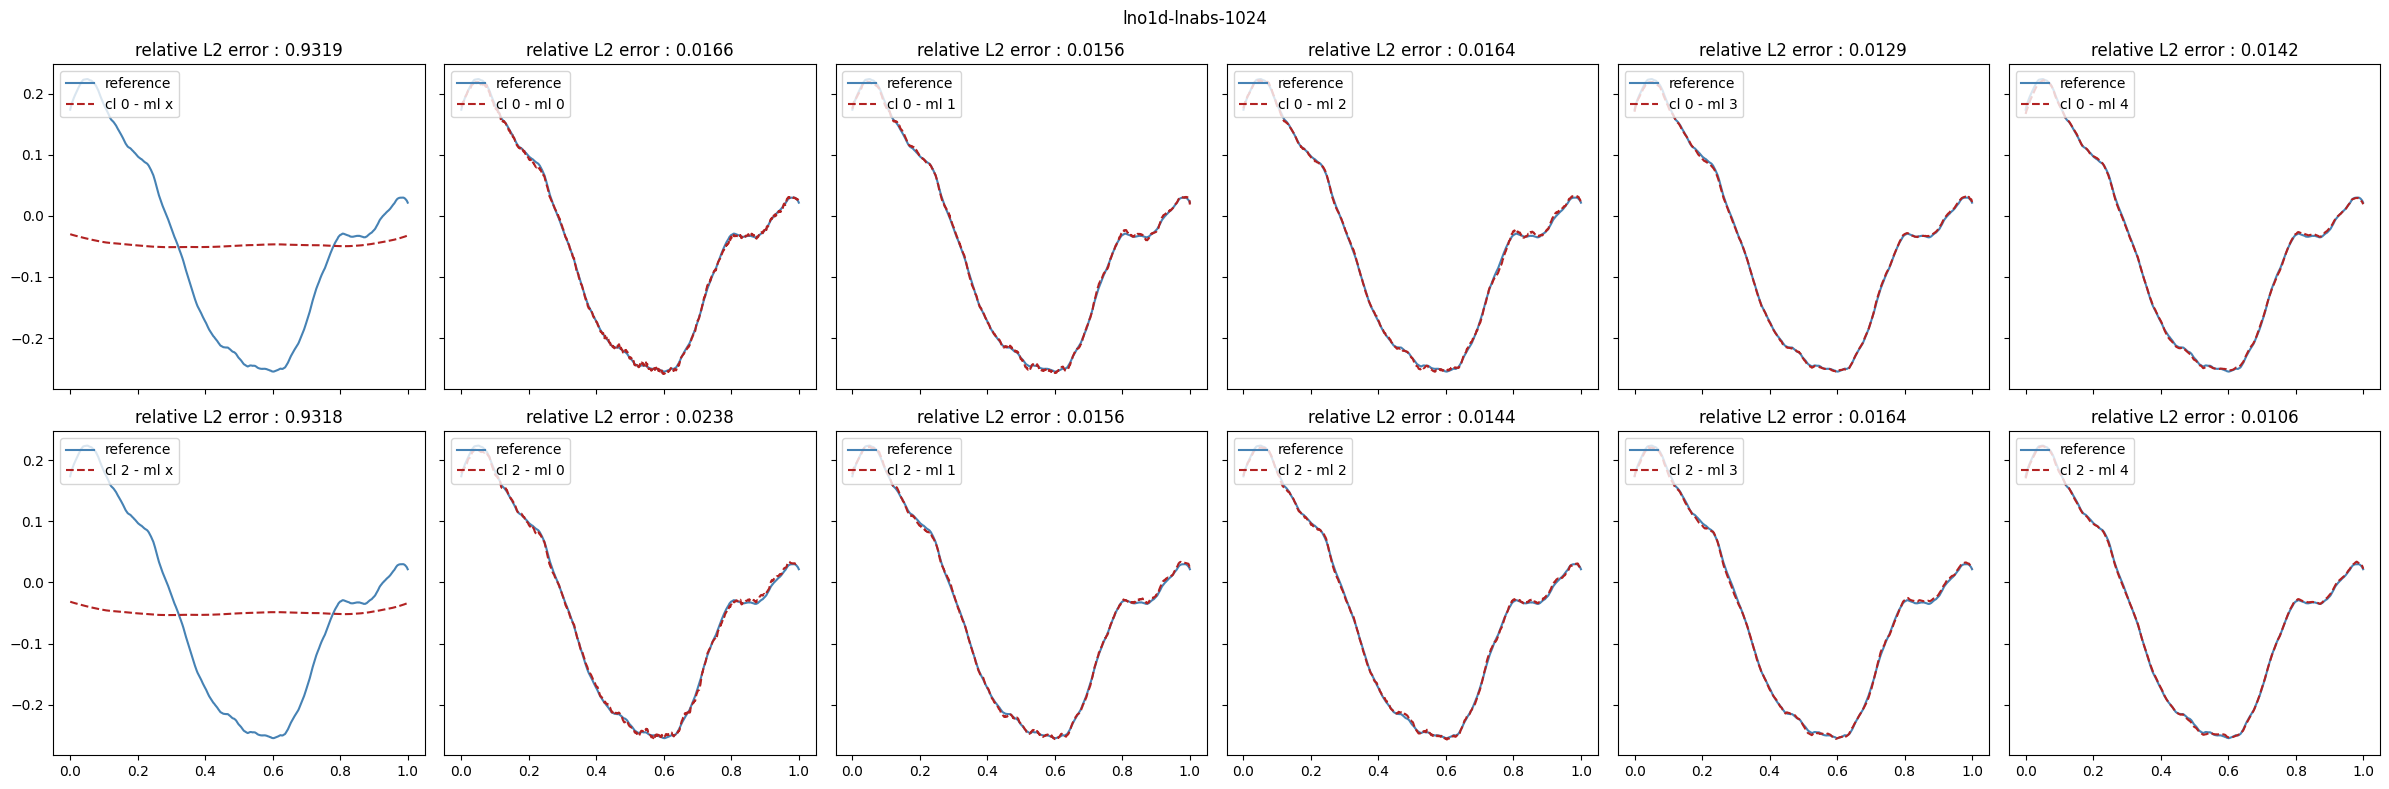

In [7]:
# fig = vis1d_sample_result(10, test_dataset, u_normalizer, log_root, 'lno1d', 'lnabs', [0, 2], ['x', 0, 1, 2, 3, 4], device, sub=8)